#Project 1 Classification


##Task 1: Data Download.
Download the Census Income (CI) Dataset and Credit Approval (CA) Dataset from Moodle to
answer the question in task 2-5.

In [94]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
# Path Direction
base_path = "/content/drive/MyDrive/DataMining/Project 1 Classification/"
census_path = base_path + "census+income/adult.data"
credit_path = base_path + "credit+approval/crx.data"

# Load
census = pd.read_csv(census_path, header=None)
credit = pd.read_csv(credit_path, header=None)

##EDA :

###1. Census Dataset

#### 1.1. Shape

In [95]:
census.shape

(32561, 15)

#### 1.2. Preview data

In [96]:
census.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#### 1.3. Data types

In [97]:
census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       32561 non-null  int64 
 1   1       32561 non-null  object
 2   2       32561 non-null  int64 
 3   3       32561 non-null  object
 4   4       32561 non-null  int64 
 5   5       32561 non-null  object
 6   6       32561 non-null  object
 7   7       32561 non-null  object
 8   8       32561 non-null  object
 9   9       32561 non-null  object
 10  10      32561 non-null  int64 
 11  11      32561 non-null  int64 
 12  12      32561 non-null  int64 
 13  13      32561 non-null  object
 14  14      32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### 1.4. Missing values

In [98]:
(census == '?').sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


#### 1.5. Class distribution

In [99]:
census.iloc[:, -1].value_counts()

,count
14,
<=50K,24720
>50K,7841


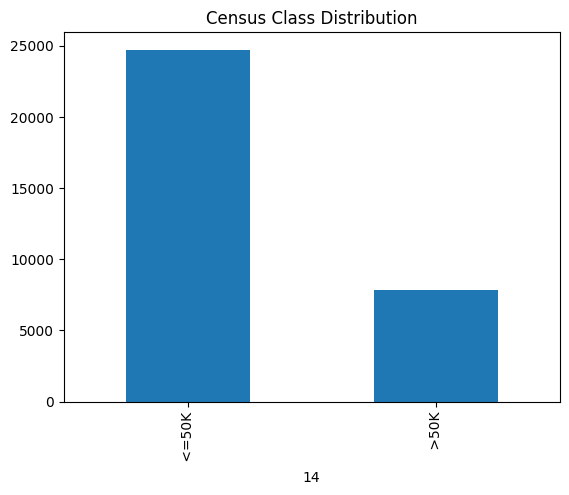

In [100]:
import matplotlib.pyplot as plt

census.iloc[:, -1].value_counts().plot(kind='bar')
plt.title("Census Class Distribution")
plt.show()

#### 1.6. Basic statistics

In [101]:
census.describe()

,0,2,4,10,11,12
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


###2. Credit Dataset

#### 2.1. Shape

In [102]:
credit.shape

(690, 16)

#### 2.2. Preview data

In [103]:
credit.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


#### 2.3. Data types

In [104]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


#### 2.4. Missing values

In [105]:
(credit == '?').sum()

,0
0,12
1,12
2,0
3,6
4,6
5,9
6,9
7,0
8,0
9,0


#### 2.5. Class distribution

In [106]:
credit.iloc[:, -1].value_counts()

,count
15,
-,383
+,307


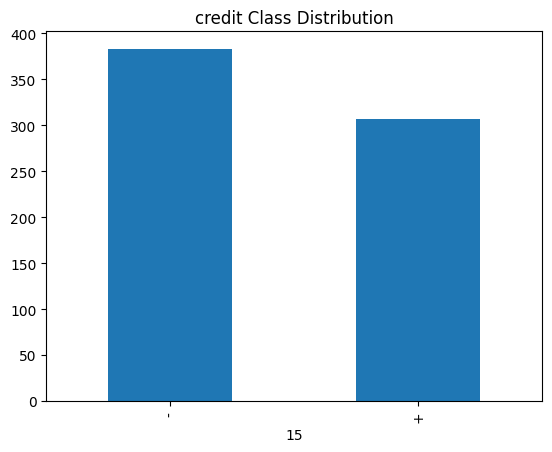

In [107]:
import matplotlib.pyplot as plt

credit.iloc[:, -1].value_counts().plot(kind='bar')
plt.title("credit Class Distribution")
plt.show()

#### 2.6. Basic statistics

In [108]:
credit.describe()

,2,7,10,14
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


##Task 2: Create Training and Test Dataset (5 points)
In this task, for each of the datasets above create a training dataset and test dataset. Make the
number of instances in training and test dataset be 80% and 20% of the original dataset.
For how to perform the splitting. use Random Sampling Without Replacement. Once you
have carried out the splitting, label the generated datasets as follow:
1. Training dataset: census trainset.txt, credit trainset.txt
2. Test dataset: census testset.txt, credit testset.txt

In [109]:

# Shuffle Random No Replacement And Split 80 20
census = shuffle(census, random_state=42)
credit = shuffle(credit, random_state=42)

def split_data(df):
    train_size = int(0.8 * len(df))
    train = df.iloc[:train_size]
    test = df.iloc[train_size:]
    return train, test

census_train, census_test = split_data(census)
credit_train, credit_test = split_data(credit)

# Save
census_train.to_csv(base_path + "census_trainset.txt", index=False, header=False)
census_test.to_csv(base_path + "census_testset.txt", index=False, header=False)

credit_train.to_csv(base_path + "credit_trainset.txt", index=False, header=False)
credit_test.to_csv(base_path + "credit_testset.txt", index=False, header=False)

print("Done")

Done


In [110]:
print(len(census_train), len(census_test))

26048 6513


In [111]:
print(len(credit_train), len(credit_test))

552 138


##Task 3: Decision Tree(DT), Random Forest (RF), and Naive Bayes (NB) Algorithm (45 points)
In this task, you will implement a R, Matlab or Python function executable file, that uses Decision
Trees, Random Forest, and Naive Bayes to train a model, and then applies the model to classify
your test data.
Your function should be invoked as follows (Matlab, R, or Python):
1. decision tree(<training file>, <test file>)
2. random forest(<training file>, <test file>)
3. naive bayes(<training file>, <test file>)
The first argument, <training file>, is the path name of the training file where the training
data is stored.
The second argument, <test file>, is the path name of the test file where the test data is
stored.
All this function should be implemented in the file named: DTvsRFvsNB.[extension of lan
guage]
Note: Your code should also work with ANY OTHER training and test files using the same
format as the files in the datasets.
Your code should be invoked as follows (e.g. Python):
python3 DTvsRFvsNB.py <training_file> <test_file>
where the first argument is the path to the training file and second argument is the path to
the test file.

##Task 4: Classification: (5 points)
For each test data instance you should print a line containing the following info:
1. Object ID. This is the line number where that object occurs in the test file. Start with 1 in
numbering the objects, not with 0.
2. Predicted class (the result of the classification)
3. True class (from the last column of the test file).
4. Accuracy. Defined as follows:
(a) Predicted Class = True Class, accuracy is 1
(b) Predicted Class ̸ = True Class, accuracy is 0
5. Format as follows (Matlab):
fprintf(’ID=%5d, predicted=%3d, true=%3d, accuracy=%4.2f\n’,
object_id, predicted_class, true_class, accuracy);

In [112]:
!python3 "/content/drive/MyDrive/DataMining/Project 1 Classification/DTvsRFvsNB.py" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/census_trainset.txt" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/census_testset.txt" \
> "/content/drive/MyDrive/DataMining/Project 1 Classification/census_full_output.log" 2>&1

In [113]:
!python3 "/content/drive/MyDrive/DataMining/Project 1 Classification/DTvsRFvsNB.py" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/credit_trainset.txt" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/credit_testset.txt"

Start


=====Decision Tree=====
ID=    1, predicted=  0, true=  0, accuracy=1.00
ID=    2, predicted=  0, true=  1, accuracy=0.00
ID=    3, predicted=  0, true=  0, accuracy=1.00
ID=    4, predicted=  0, true=  0, accuracy=1.00
ID=    5, predicted=  0, true=  1, accuracy=0.00
ID=    6, predicted=  0, true=  0, accuracy=1.00
ID=    7, predicted=  1, true=  1, accuracy=1.00
ID=    8, predicted=  1, true=  0, accuracy=0.00
ID=    9, predicted=  0, true=  0, accuracy=1.00
ID=   10, predicted=  0, true=  0, accuracy=1.00
ID=   11, predicted=  1, true=  1, accuracy=1.00
ID=   12, predicted=  0, true=  1, accuracy=0.00
ID=   13, predicted=  1, true=  0, accuracy=0.00
ID=   14, predicted=  0, true=  0, accuracy=1.00
ID=   15, predicted=  1, true=  1, accuracy=1.00
ID=   16, predicted=  0, true=  0, accuracy=1.00
ID=   17, predicted=  1, true=  1, accuracy=1.00
ID=   18, predicted=  0, true=  0, accuracy=1.00
ID=   19, predicted=  1, true=  1, accuracy=1.00
ID=   20, predicted=  1, true=  1, ac

##Task 6: Handling Missing Data (30 points)
In this task, you will pick ONE of the three ways, described in our lecture slide on chapter 2
(slide 30), for Handling Missing Data to resolve the missing data in some attributes in the Credit
Approval Dataset.
Once you have decided on the technique to use to handle the missing data, perform Task 2
and 3 only on the Dataset.
Report the following:

In [114]:
import pandas as pd
from sklearn.utils import shuffle


base_path = "/content/drive/MyDrive/DataMining/Project 1 Classification/"
credit_path = base_path + "credit+approval/crx.data"
credit = pd.read_csv(credit_path, header=None)

# Handle missing values
credit.replace('?', pd.NA, inplace=True)
for col in credit.columns:
    credit[col].fillna(credit[col].mode()[0], inplace=True)

print("Missing values handled.")


# Shuffle And Split 80 20
# -----------------------------
credit = shuffle(credit, random_state=42)
train_size = int(0.8 * len(credit))

train = credit.iloc[:train_size]
test = credit.iloc[train_size:]

# Save
train.to_csv(base_path + "Task6_credit_trainset.txt", index=False, header=False)
test.to_csv(base_path + "Task6_credit_testset.txt", index=False, header=False)

print("Done")

Missing values handled.
Done


/tmp/ipykernel_3013/3589683369.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credit[col].fillna(credit[col].mode()[0], inplace=True)
/tmp/ipykernel_3013/3589683369.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [115]:
!python3 "/content/drive/MyDrive/DataMining/Project 1 Classification/DTvsRFvsNB.py" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/Task6_credit_trainset.txt" \
"/content/drive/MyDrive/DataMining/Project 1 Classification/Task6_credit_testset.txt"

Start


=====Decision Tree=====
ID=    1, predicted=  1, true=  0, accuracy=0.00
ID=    2, predicted=  0, true=  1, accuracy=0.00
ID=    3, predicted=  0, true=  0, accuracy=1.00
ID=    4, predicted=  0, true=  0, accuracy=1.00
ID=    5, predicted=  1, true=  1, accuracy=1.00
ID=    6, predicted=  0, true=  0, accuracy=1.00
ID=    7, predicted=  1, true=  1, accuracy=1.00
ID=    8, predicted=  1, true=  0, accuracy=0.00
ID=    9, predicted=  0, true=  0, accuracy=1.00
ID=   10, predicted=  0, true=  0, accuracy=1.00
ID=   11, predicted=  1, true=  1, accuracy=1.00
ID=   12, predicted=  1, true=  1, accuracy=1.00
ID=   13, predicted=  1, true=  0, accuracy=0.00
ID=   14, predicted=  1, true=  0, accuracy=0.00
ID=   15, predicted=  1, true=  1, accuracy=1.00
ID=   16, predicted=  0, true=  0, accuracy=1.00
ID=   17, predicted=  1, true=  1, accuracy=1.00
ID=   18, predicted=  1, true=  0, accuracy=0.00
ID=   19, predicted=  1, true=  1, accuracy=1.00
ID=   20, predicted=  1, true=  1, ac

In [116]:
print(train.shape)
print(test.shape)

(552, 16)
(138, 16)


In [117]:
print(len(train), len(test))

552 138
